# CS 4412 – Data Mining  
## Milestone 2: Exploratory Analysis and Initial Mining  
Tate York

This notebook constructs a dataset of MLB player seasons using the Lahman
Baseball Database and performs exploratory data analysis to understand
patterns in offensive performance and player aging.

The goal of this milestone is to examine the dataset structure, visualize
important relationships, and apply an initial data mining technique to
identify patterns among player performance profiles.

In [1]:
import sys
print(sys.executable)

C:\Users\tyork\OneDrive\Desktop\cs4412-baseball-aging\.venv\Scripts\python.exe


## Loading Raw Data

The Lahman Baseball Database is used as the primary data source for this
analysis. The Batting table contains season-level offensive statistics,
while the People table provides player birth year information that allows
player age to be calculated for each season.

In [3]:
import pandas as pd
from pathlib import Path

lahman_dir = Path("../data/raw/lahman")

batting = pd.read_csv(lahman_dir / "Batting.csv")
people  = pd.read_csv(lahman_dir / "People.csv")

print("Batting:", batting.shape)
print("People:", people.shape)

batting.head()

Batting: (110495, 22)
People: (20673, 24)


,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,...,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
0,abercda01,1871,1,TRO,NaN,1,4,0,0,0,...,0.0,0.0,0.0,0,0.0,NaN,NaN,NaN,NaN,0.0
1,addybo01,1871,1,RC1,NaN,25,118,30,32,6,...,13.0,8.0,1.0,4,0.0,NaN,NaN,NaN,NaN,0.0
2,allisar01,1871,1,CL1,NaN,29,137,28,40,4,...,19.0,3.0,1.0,2,5.0,NaN,NaN,NaN,NaN,1.0
3,allisdo01,1871,1,WS3,NaN,27,133,28,44,10,...,27.0,1.0,1.0,0,2.0,NaN,NaN,NaN,NaN,0.0
4,ansonca01,1871,1,RC1,NaN,25,120,29,39,11,...,16.0,6.0,2.0,2,1.0,NaN,NaN,NaN,NaN,0.0


## Dataset Construction and Feature Engineering

The raw batting dataset contains multiple entries per player-season due to
team changes within a season. To simplify analysis, statistics are aggregated
so that each row represents a single player-season.

Several offensive metrics are then calculated including batting average,
on-base percentage, slugging percentage, and OPS. Player age is also derived
using the difference between the season year and the player's birth year.

In [4]:
# Filter modern seasons
bat = batting[batting["yearID"].between(1980, 2025)].copy()

# Ensure required columns exist
needed = ["playerID","yearID","lgID","G","AB","H","2B","3B","HR","BB","SO","HBP","SF"]
for c in needed:
    if c not in bat.columns:
        bat[c] = 0

bat = bat[needed].copy()

# Combine multi-team seasons into one row per player-season
sum_cols = ["G","AB","H","2B","3B","HR","BB","SO","HBP","SF"]
ps = bat.groupby(["playerID","yearID","lgID"], as_index=False)[sum_cols].sum()

# Merge birth year to compute player age
people_small = people[["playerID","birthYear"]]
ps = ps.merge(people_small, on="playerID", how="left")

ps["Age"] = ps["yearID"] - ps["birthYear"]

# Plate appearances
ps["PA"] = ps["AB"] + ps["BB"] + ps["HBP"] + ps["SF"]

# Rate statistics
ps["BA"]  = ps["H"] / ps["AB"]
ps["OBP"] = (ps["H"] + ps["BB"] + ps["HBP"]) / (ps["AB"] + ps["BB"] + ps["HBP"] + ps["SF"])
ps["SLG"] = (ps["H"] + ps["2B"] + 2*ps["3B"] + 3*ps["HR"]) / ps["AB"]
ps["OPS"] = ps["OBP"] + ps["SLG"]

# Clean data
ps = ps.dropna(subset=["Age","OPS","OBP","SLG","BA","PA"])
ps = ps[(ps["Age"] > 0) & (ps["Age"] < 60)]
ps = ps[ps["PA"] >= 200]

ps.rename(columns={"yearID":"Season","lgID":"Lg"}, inplace=True)

ps.shape

(13412, 20)

In [5]:
# Compute league average OPS for each season and league
lg_ops = ps.groupby(["Season","Lg"], as_index=False)["OPS"].mean()
lg_ops = lg_ops.rename(columns={"OPS":"LgAvgOPS"})

ps = ps.merge(lg_ops, on=["Season","Lg"], how="left")

# OPS+ approximation (league adjusted only)
ps["OPS_plus_lg"] = 100 * (ps["OPS"] / ps["LgAvgOPS"])

ps[["playerID","Season","Age","PA","OPS","LgAvgOPS","OPS_plus_lg"]].head()

,playerID,Season,Age,PA,OPS,LgAvgOPS,OPS_plus_lg
0,abbotje01,1998,26.0,258.0,0.790253,0.765174,103.277552
1,abbotje01,2000,28.0,239.0,0.738445,0.794566,92.936889
2,abbotku01,1994,25.0,368.0,0.684964,0.780189,87.794639
3,abbotku01,1995,26.0,466.0,0.769978,0.769916,100.007988
4,abbotku01,1996,27.0,345.0,0.735371,0.764819,96.149724


## Dataset Summary

After preprocessing, the dataset consists of one row per player-season.
Basic statistics are calculated to understand the scale of the dataset,
including number of observations, number of unique players, and the range
of seasons represented.

In [ ]:
df = ps.copy()

out_path = "../data/mlb_player_seasons_1980_2025_lahman_batting.csv"
df.to_csv(out_path, index=False)

rows, cols = df.shape
mem_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
unique_players = df["playerID"].nunique()

print(f"Dataset: {rows:,} rows × {cols} columns")
print(f"Memory usage: {mem_mb:.2f} MB")
print(f"Unique players: {unique_players:,}")
print("Seasons:", int(df["Season"].min()), "-", int(df["Season"].max()))

df.sample(10, random_state=42)

## Exploratory Data Analysis (EDA)

Before applying mining techniques, the dataset is explored to understand
the distribution of player ages, performance trends, and potential biases
in the data. These visualizations help guide preprocessing decisions and
feature selection for clustering.

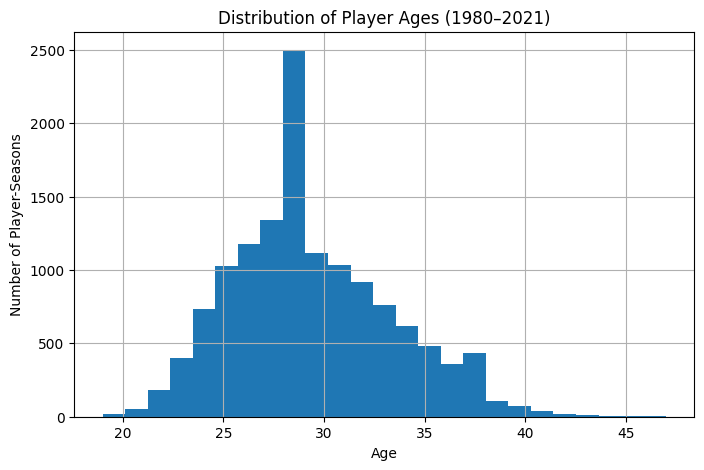

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df["Age"].hist(bins=25)

plt.title("Distribution of Player Ages (1980–2021)")
plt.xlabel("Age")
plt.ylabel("Number of Player-Seasons")

plt.show()

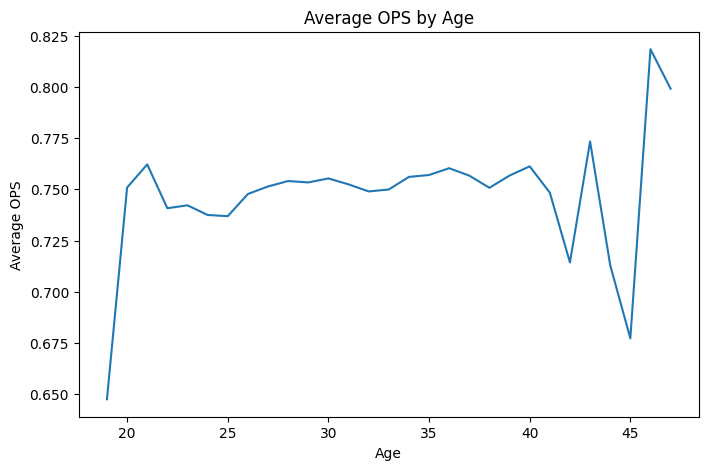

In [8]:
age_perf = df.groupby("Age")["OPS"].mean()

plt.figure(figsize=(8,5))
plt.plot(age_perf.index, age_perf.values)

plt.title("Average OPS by Age")
plt.xlabel("Age")
plt.ylabel("Average OPS")

plt.show()

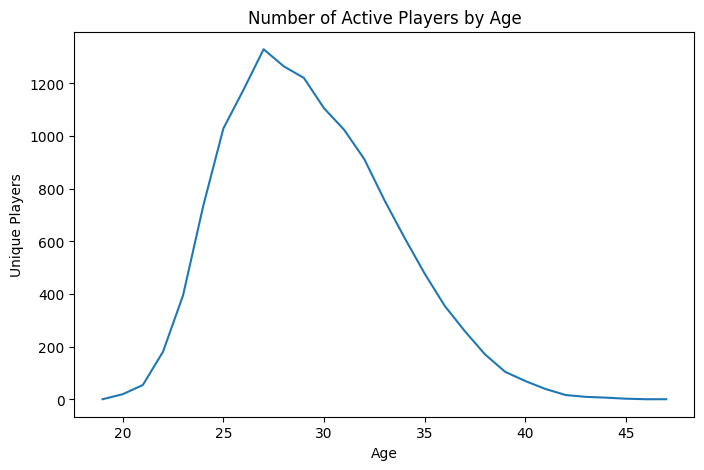

In [9]:
players_by_age = df.groupby("Age")["playerID"].nunique()

plt.figure(figsize=(8,5))
plt.plot(players_by_age.index, players_by_age.values)

plt.title("Number of Active Players by Age")
plt.xlabel("Age")
plt.ylabel("Unique Players")

plt.show()

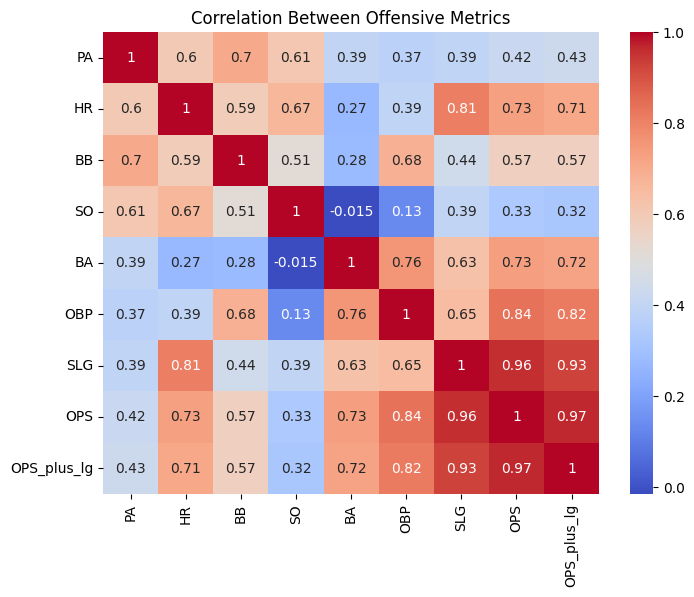

In [10]:
import seaborn as sns

features = ["PA","HR","BB","SO","BA","OBP","SLG","OPS","OPS_plus_lg"]

corr = df[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between Offensive Metrics")

plt.show()

## Clustering Analysis

To identify groups of similar player performance profiles, K-Means clustering
is applied to the offensive statistics in the dataset. The goal is to discover
natural groupings of players based on hitting style and productivity.

Features used for clustering include batting average (BA), on-base percentage
(OBP), slugging percentage (SLG), home runs (HR), strikeouts (SO), and OPS+.
These metrics capture both power hitting and overall offensive efficiency.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ["BA","OBP","SLG","HR","SO","OPS_plus_lg"]

X = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_cluster = df.loc[X.index].copy()
df_cluster["cluster"] = clusters

df_cluster.head()

,playerID,Season,Lg,G,AB,H,2B,3B,HR,BB,...,birthYear,Age,PA,BA,OBP,SLG,OPS,LgAvgOPS,OPS_plus_lg,cluster
0,abbotje01,1998,AL,89,244,68,14,1,12,9,...,1972.0,26.0,258.0,0.278689,0.298450,0.491803,0.790253,0.765174,103.277552,1
1,abbotje01,2000,AL,80,215,59,15,1,3,21,...,1972.0,28.0,239.0,0.274419,0.343096,0.395349,0.738445,0.794566,92.936889,1
2,abbotku01,1994,NL,101,345,86,17,3,9,16,...,1969.0,25.0,368.0,0.249275,0.290761,0.394203,0.684964,0.780189,87.794639,2
3,abbotku01,1995,NL,120,420,107,18,7,17,36,...,1969.0,26.0,466.0,0.254762,0.317597,0.452381,0.769978,0.769916,100.007988,0
4,abbotku01,1996,NL,109,320,81,18,7,8,22,...,1969.0,27.0,345.0,0.253125,0.307246,0.428125,0.735371,0.764819,96.149724,0


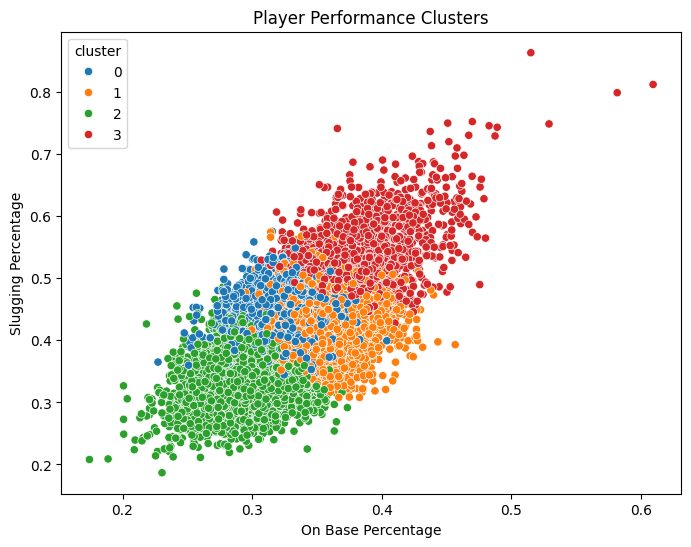

In [12]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_cluster["OBP"],
    y=df_cluster["SLG"],
    hue=df_cluster["cluster"],
    palette="tab10"
)

plt.title("Player Performance Clusters")
plt.xlabel("On Base Percentage")
plt.ylabel("Slugging Percentage")

plt.show()

### Interpretation

The clustering results reveal several distinct offensive profiles among players.
One cluster represents high-power hitters with strong slugging percentages and
higher home run totals. Another cluster includes contact-oriented hitters with
higher batting averages but lower power production.

These clusters demonstrate that player offensive performance naturally groups
into recognizable categories. This supports the hypothesis that player aging
patterns and performance trajectories may differ depending on the offensive
profile of the player.

## Summary and Next Steps

This milestone constructed a cleaned dataset of MLB player seasons using
the Lahman database and explored patterns in offensive performance using
visualizations. Clustering analysis revealed distinct offensive player
profiles based on hitting statistics.

Future work will expand on these findings by analyzing how player
performance changes over time and investigating aging curves for
different types of hitters.